In [1]:
%load_ext autoreload
%autoreload 2
%matplotlib widget

import os
from config.loader import load_config
#from utils.plotting import apply_style
from core.mesh_generator import MeshGenerator
from core.density_generator import DensityProfileBuilder
from utils.antenna_desc_2D import AntennaGrill as ant
from core.mesh_refiner import WKBRefiner
from core.physics_solver import LowerHybridSolver
import utils.plot_density_profile as ne_plt
from utils.plot_mesh_refinement_diag import plot_true_mesh_size


# .os.path.join("folder_name", "inputs_file_name")
yaml_path = os.path.join("config", "input_antenna_none.yaml")
config = load_config(yaml_path)

--- Configuration successfully loaded and validated from config/input_antenna_none.yaml ---


In [2]:
print("\n--- Generating Base Mesh ---")
mesh_gen = MeshGenerator(config)
base_mesh = mesh_gen.generate_base_mesh(save_mesh_file=True)
print(f"Base mesh generated with {base_mesh.ne} elements.")

print("\n--- Building Density Profile ---")
density_builder = DensityProfileBuilder(config)
bg_ne_cf, tot_ne_cf = density_builder.build_from_config(base_mesh)


--- Generating Base Mesh ---
--- Lz_plasma: 1.000e-01m ---


AttributeError: 'NoneType' object has no attribute 'dimensions'


--- Plot density profiles ---
--- Generating 1D Radial Cut at z = 0.1500 m ---
x_min=-0.080 m, x_max=0.130 m


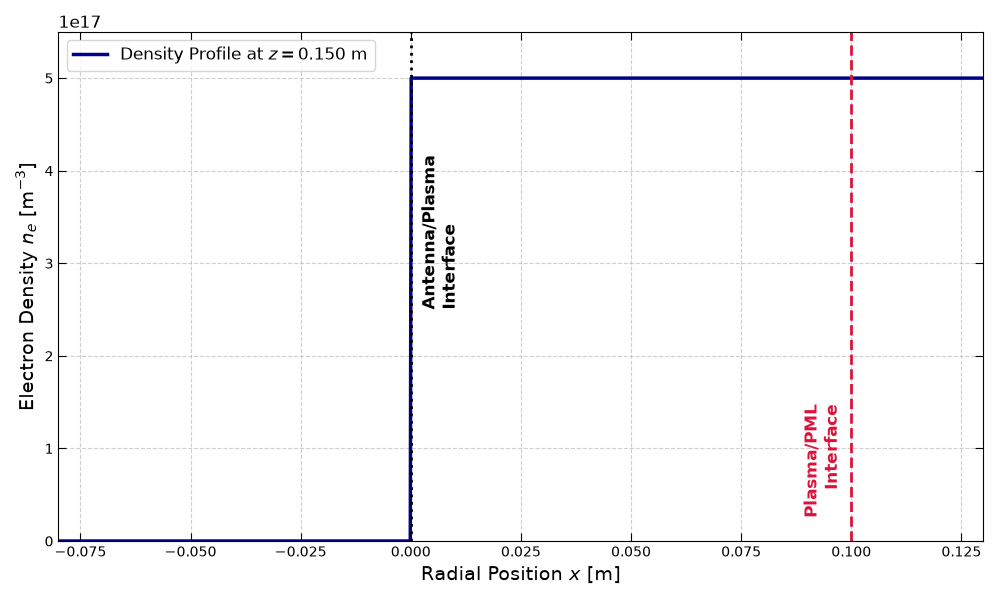

In [ ]:
import utils.plot_density_profile as ne_plt

print("\n--- Plot density profiles ---")
ne_plt.plot_1d_radial_cut(config, base_mesh, tot_ne_cf, z_eval=0.15)
# ne_plt.plot_2d_density_perturbation(config, base_mesh, bg_ne_cf, tot_ne_cf)
# ne_plt.plot_density_3d(config, base_mesh, tot_ne_cf)

In [ ]:
# Show coarse mesh before WKB refinement
# plot_true_mesh_size(config, base_mesh, "Coarse Base Mesh (Before A-Priori)")

In [ ]:
# Execute the C++ physics refiner
refiner = WKBRefiner(config, base_mesh)
refined_mesh = refiner.apply_apriori_refinement(tot_ne_cf, max_passes=10)


--- Initiating A-Priori WKB Mesh Refinement ---
Pass 1: Refined 115 elements.
Pass 2: Refined 176 elements.
Pass 3: Refined 0 elements.
A-Priori Refinement Converged.


In [ ]:
# plot_true_mesh_size(config, refined_mesh, "Physics-Aware Mesh (After A-Priori)")

In [ ]:
print("\n--- Initiating Full-Wave Solver & AMR ---")
solver = LowerHybridSolver(config, refined_mesh)

# This will solve, check the flux-jump error around the antenna corners, refine, and re-solve
solver.apply_aposteriori_amr(tot_ne_cf, max_steps=4, tolerance=1e-5)


--- Initiating Full-Wave Solver & AMR ---

--- A-Posteriori AMR Step 1/4 ---
--- Solving full-wave system with 56871 DoFs ---
--- Linear System Solved Successfully ---
Maximum Element Error: 3.87e+06
Marking 7 elements for refinement around singularities/gradients.

--- A-Posteriori AMR Step 2/4 ---
--- Solving full-wave system with 57578 DoFs ---
--- Linear System Solved Successfully ---
Maximum Element Error: 5.85e+05
Marking 28 elements for refinement around singularities/gradients.

--- A-Posteriori AMR Step 3/4 ---
--- Solving full-wave system with 60642 DoFs ---
--- Linear System Solved Successfully ---
Maximum Element Error: 5.88e+05
Marking 65 elements for refinement around singularities/gradients.

--- A-Posteriori AMR Step 4/4 ---
--- Solving full-wave system with 67902 DoFs ---
--- Linear System Solved Successfully ---
Maximum Element Error: 1.40e+06
Marking 42 elements for refinement around singularities/gradients.


In [ ]:
from utils.data_extraction import extract_2d_wave_map
from utils.plot_E_map import plot_2d_wave_map

run_output_dir = os.path.join("Results", "Current_Run")
os.makedirs(run_output_dir, exist_ok=True)


In [ ]:
h5_file = extract_2d_wave_map(config, refined_mesh, solver.E_field, save_dir=run_output_dir, nx=1000, nz=1000)


--- Extracting 2D Wave Map (Optimized C++ Interpolation) ---
--- Data strictly extracted and saved to Results/Current_Run/Wave_Map_2D.h5 ---


--- Plotting 2D Map from Results/Current_Run/Wave_Map_2D.h5 ---


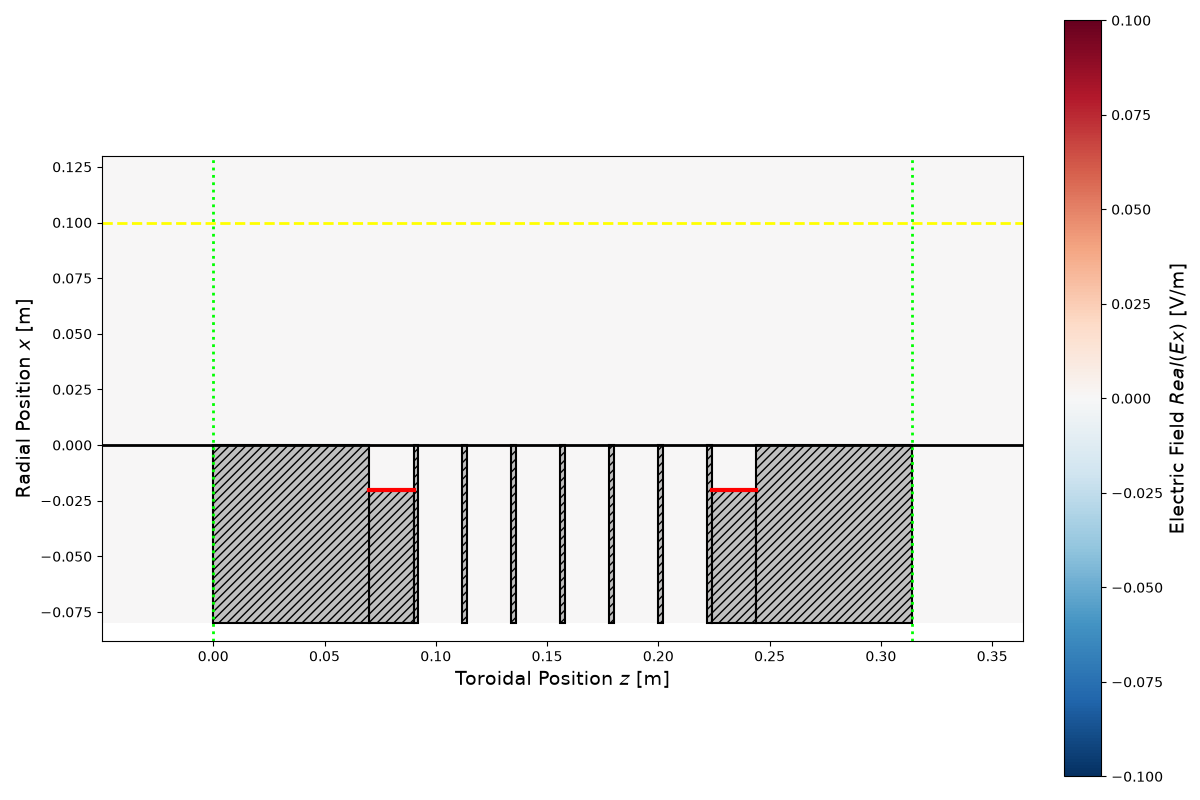

--- Plotting 2D Map from Results/Current_Run/Wave_Map_2D.h5 ---


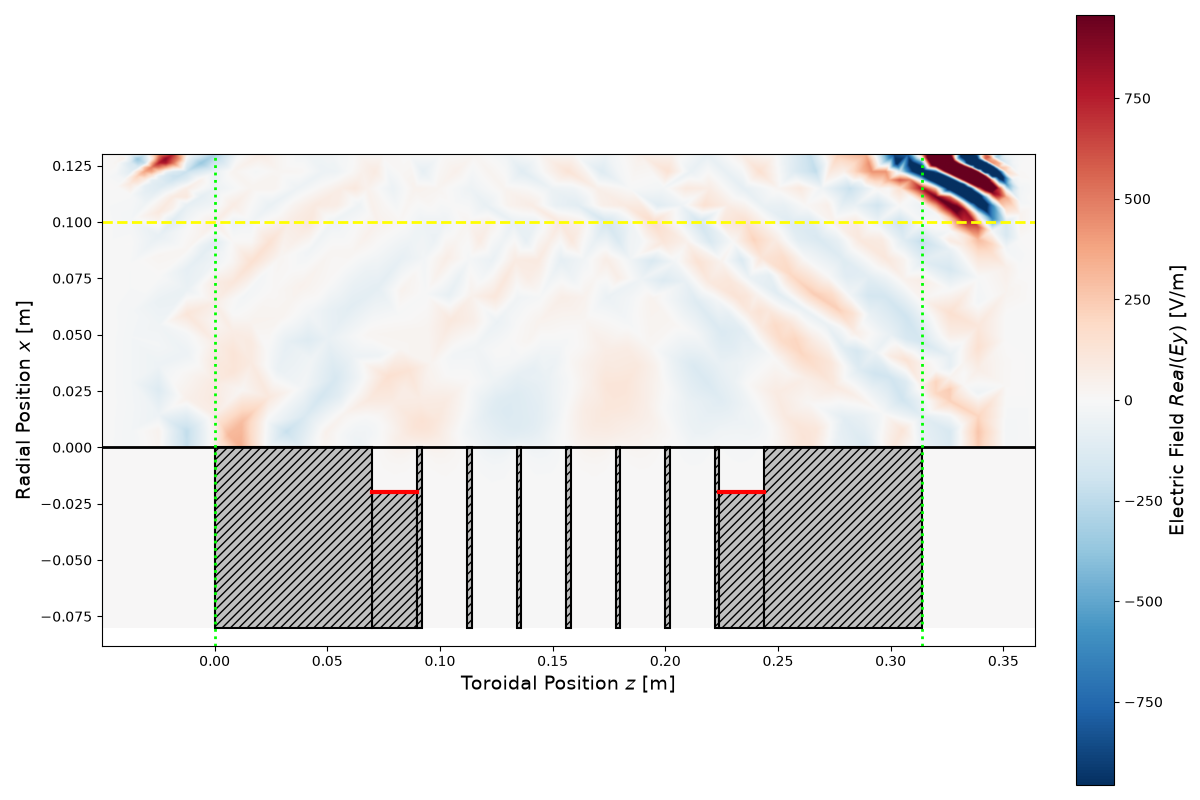

--- Plotting 2D Map from Results/Current_Run/Wave_Map_2D.h5 ---


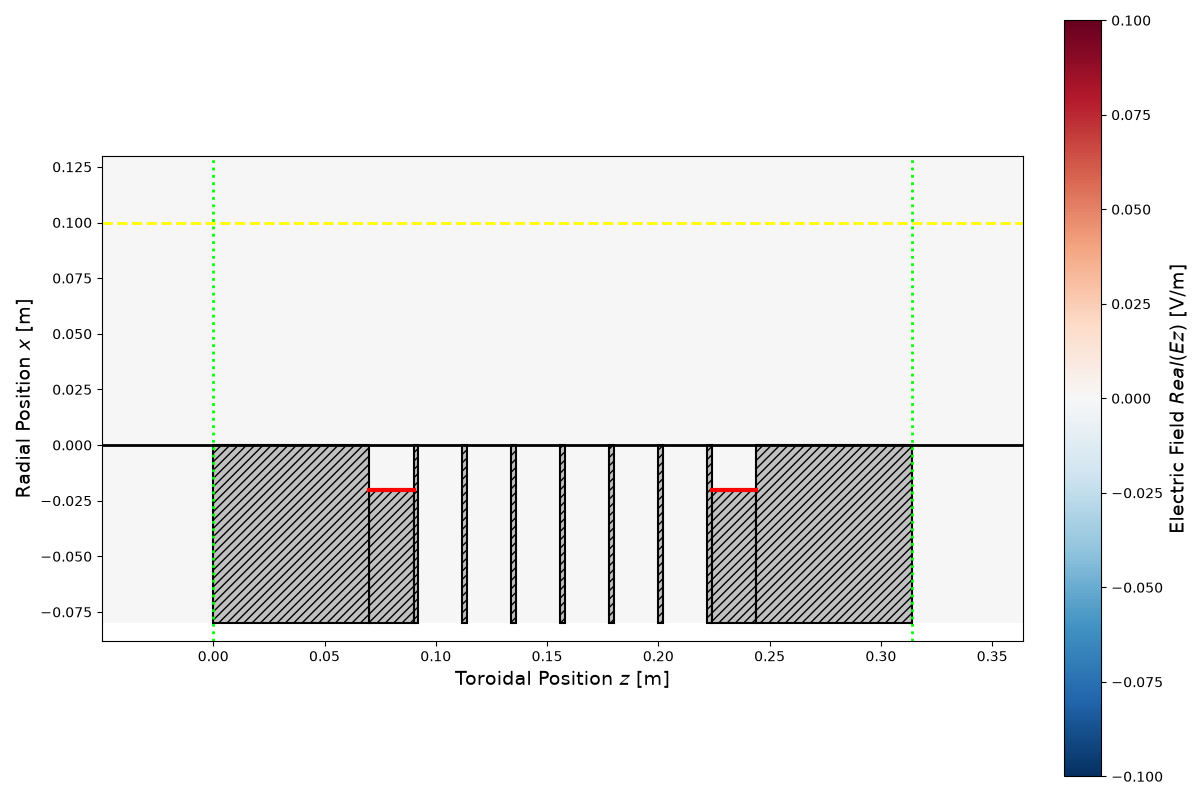

--- Plotting 2D Map from Results/Current_Run/Wave_Map_2D.h5 ---


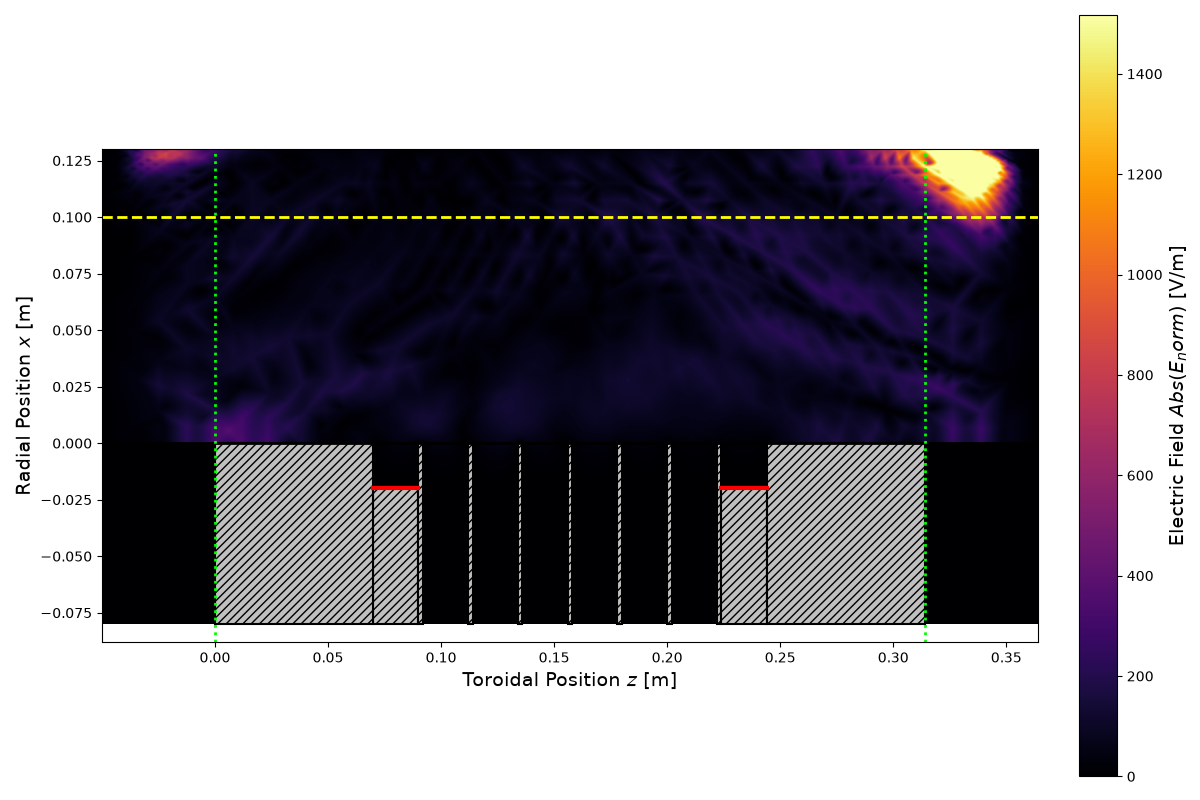

In [ ]:

plot_2d_wave_map(config, h5_file, component='Ex', value_type='real')
plot_2d_wave_map(config, h5_file, component='Ey', value_type='real')
plot_2d_wave_map(config, h5_file, component='Ez', value_type='real')


plot_2d_wave_map(config, h5_file, component='E_norm', value_type='abs')

In [ ]:
from core.physics_post_process import PhysicsPostProcessor
post = PhysicsPostProcessor(config, refined_mesh, solver.E_field)

P_net = post.compute_net_port_power()
s_params = post.extract_active_s_parameters()

print(f"Net Coupled Power: {P_net:.3f} W")
for wg, data in s_params.items():
    print(f"  {wg}: |Gamma|^2 = {data['Power_Reflectivity']:.4f}, Phase = {data['Phase_deg']:.1f}°")

AttributeError: 'DomainConfig' object has no attribute 'Lz_wall'

In [ ]:
n_para, dP_dn = post.compute_exact_poynting_spectrum(x_eval=0.002)